In [1]:
import numpy as np
import gymnasium as gym
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
#Render dell'ambiente per visualizzare i risultati dell'apprendimento per rinforzo
env = gym.make("Taxi-v3", render_mode="human")
env.reset()
env.render()

In [56]:
state_space = env.observation_space.n
print("Stati possibili: ", state_space)
action_space = env.action_space.n
print("Azioni possibili: ", action_space)

Stati possibili:  500
Azioni possibili:  6


In [57]:
#Creazione Q-table per visualizzare la heatmap dei reward per stato/azione
Q = np.zeros((state_space, action_space))
print(Q)
print(Q.shape)

[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
(500, 6)


In [58]:
#Iperparametri

total_episodes = 10           #Episodi di addestramento
total_test_episodes = 10      #Episodi di test
max_steps = 100               #Step per pisodio

learning_rate = 0.01          #Learning rate
gamma = 0.99                  #Discounting rate

# Exploration parameters
epsilon = 1.0                 #Exploration rate
max_epsilon = 1.0             #Probabilità esplorazione allo stato start
min_epsilon = 0.001           #Probabilità minima di esplorazione
decay_rate = 0.01             #Decay esponenziale

In [59]:
#Funzione epsilon greedy che in base al valore di epsilon decide se usare un'azione random o quella ottimale
#L'epsilon decresce durante l'addestramento per premiare sempre di più l'uso di azioni ottimali
def epsilon_greedy_policy(Q, state):
  if(random.uniform(0,1) > epsilon): #se random > epsilon --> explotation(viene selezionata l'azione con la coppia state-value migliore)
    action = np.argmax(Q[state])
  #se random < epsilon --> exploration(viene provata un'azione random)
  else:
    action = env.action_space.sample()
  
  return action

In [60]:
#Algoritmo di Q Learning
for episode in range(total_episodes):
    #Reset environment
    state, _ = env.reset()
    step = 0
    done = False

    #Decremento epsilon
    epsilon = min_epsilon + (max_epsilon - min_epsilon)*np.exp(-decay_rate*episode)

    for step in range(max_steps):
        print(f"Episodio {episode}-step {step}")
        #Scelta azione tramite epsilon greedy policy
        action = epsilon_greedy_policy(Q, state)
        print(f"Azione: {action}")

        #Effettua l'azione action(a) osservando new_state(s) e reward(r)
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        #Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
        Q[state][action] = Q[state][action] + learning_rate * (reward + gamma * 
                                    np.max(Q[new_state]) - Q[state][action])
        print(f"Q[{state}][{action}]: {Q[state][action]}\n")      
        #Fine episodio
        if done == True: 
            break
        
        #Nuovo stato
        state = new_state

Episodio 0-step 0
Azione: 2
Q[332][2]: -0.01

Episodio 0-step 1
Azione: 3
Q[352][3]: -0.01

Episodio 0-step 2
Azione: 4
Q[332][4]: -0.1

Episodio 0-step 3
Azione: 5
Q[332][5]: -0.1

Episodio 0-step 4
Azione: 4
Q[332][4]: -0.199

Episodio 0-step 5
Azione: 1
Q[332][1]: -0.01

Episodio 0-step 6
Azione: 1
Q[232][1]: -0.01

Episodio 0-step 7
Azione: 1
Q[132][1]: -0.01

Episodio 0-step 8
Azione: 3
Q[32][3]: -0.01

Episodio 0-step 9
Azione: 5
Q[12][5]: -0.1

Episodio 0-step 10
Azione: 0
Q[12][0]: -0.01

Episodio 0-step 11
Azione: 4
Q[112][4]: -0.1

Episodio 0-step 12
Azione: 1
Q[112][1]: -0.01

Episodio 0-step 13
Azione: 0
Q[12][0]: -0.0199

Episodio 0-step 14
Azione: 1
Q[112][1]: -0.0199

Episodio 0-step 15
Azione: 0
Q[12][0]: -0.029701

Episodio 0-step 16
Azione: 1
Q[112][1]: -0.029701

Episodio 0-step 17
Azione: 2
Q[12][2]: -0.01

Episodio 0-step 18
Azione: 1
Q[32][1]: -0.01

Episodio 0-step 19
Azione: 0
Q[32][0]: -0.01

Episodio 0-step 20
Azione: 3
Q[132][3]: -0.01

Episodio 0-step 21
Azi

In [61]:
import time
rewards = []

frames = []
for episode in range(total_test_episodes):
    state, _ = env.reset()
    step = 0
    done = False
    total_rewards = 0
    print("****************************************************")
    print("EPISODE ", episode)
    for step in range(max_steps):
        env.render()     
        #Scegli l'azione che ha il massimo expected future reward
        action = np.argmax(Q[state])
        new_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_rewards += reward
        
        if done:
            rewards.append(total_rewards)
            break
        state = new_state
env.close()
print ("Score over time: " +  str(sum(rewards)/total_test_episodes))

****************************************************
EPISODE  0
****************************************************
EPISODE  1
****************************************************
EPISODE  2
****************************************************
EPISODE  3
****************************************************
EPISODE  4


KeyboardInterrupt: 

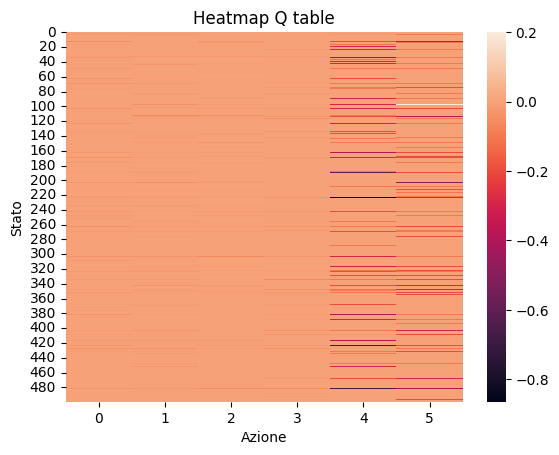

: 

In [ ]:
sns.heatmap(Q)
plt.xlabel("Azione")
plt.ylabel("Stato")
plt.title("Heatmap Q table")
plt.show()